# 01 — First circuit and load flow: IEEE 4-Node Feeder

**Goal:** run the standard IEEE 4-Node radial distribution feeder benchmark, inspect the solved network with step-down transformer and line, then verify the saved evidence.

**Teaching inputs:** IEEE 4-Node Feeder: 12.47 kV source, 0.61 km (2,000 ft) primary line, 6 MVA Dyn1 step-down transformer (12.47 / 4.16 kV), 0.76 km (2,500 ft) secondary line, and 1,800 kW load at PF 0.90.

**Prediction:** voltage will step down at the transformer (with a -30° phase shift) and drop along the secondary feeder to approximately 0.948 pu at the load bus (Node 4).

Run the numbered cells in order. The direct OpenDSS section at the end is optional.

In [1]:
#@title 1. Setup — run once
from hashlib import sha256
from urllib.request import urlopen

_bootstrap_url = "https://raw.githubusercontent.com/sarutesri/cept-studio-edu/main/public/notebooks/_lesson.py"
_bootstrap = urlopen(_bootstrap_url, timeout=60).read()
if sha256(_bootstrap).hexdigest() != "aa5805c306987984ba7ee64d57763db1938cb06052cf80e0f8f26fa84efba30d":
    raise ValueError("Lesson helper hash mismatch")
exec(compile(_bootstrap, "cept-lesson", "exec"), globals())


CEPT_WHEEL_URL not supplied; using the existing installed environment.
CLI: cept --version


cept-power-studio 0.2.0.dev0
Lesson helpers ready. Stage cells below run the same CEPT commands as a normal terminal.


In [2]:
#@title 2. Inputs — IEEE 4-Node Feeder
CASE_PATH = WORKSPACE / "first_circuit_case.json"
CASE_PAYLOAD = ieee4_node_case()
CASE_PATH.write_text(json.dumps(CASE_PAYLOAD, indent=2) + "\n", encoding="utf-8")
RUN_DIR = WORKSPACE / "runs" / "01-first-circuit"

table(
    ["declared input", "value", "unit"],
    [
        ("primary voltage", 12.47, "kV"),
        ("transformer T1", "12.47 / 4.16 kV, Dyn1, 6 MVA", "spec"),
        ("secondary voltage", 4.16, "kV"),
        ("line 1-2 length", 0.61, "km (2,000 ft)"),
        ("line 3-4 length", 0.76, "km (2,500 ft)"),
        ("load at node 4", 1800.0, "kW"),
        ("load power factor", 0.90, "1"),
    ],
)

declared input      value                           unit
------------------  ------------------------------  --------------
primary voltage     12.47                           kV
transformer T1      12.47 / 4.16 kV, Dyn1, 6 MVA    spec
secondary voltage   4.16                            kV
line 1-2 length     0.61                            km (2,000 ft)
line 3-4 length     0.76                            km (2,500 ft)
load at node 4      1800.0                          kW
load power factor   0.9                             1


In [3]:
# 3. Run study — same CEPT CLI as a normal terminal
!cept study run first_circuit_case.json \
    --out runs/01-first-circuit \
    --force \
    --format text

CEPT study result: FINISHED
----------------------------
Result             Finished the balanced load flow and saved the evidence.
Study type         Load flow (OpenDSS)
Case fingerprint   38ef70def0c3 (matches the case you ran)
Engine             OpenDSS
Artifacts          runs/01-first-circuit
Status             PASSED (5 solver checks passed)
Claim              WORKFLOW_VALIDATED

Next: verify this exact saved run with
  cept study verify runs/01-first-circuit --format text


In [4]:
#@title 4. Explore — SLD and bus status
RUN_DIR = WORKSPACE / "runs" / "01-first-circuit"
display_sld(RUN_DIR)

Bus,Phase A,Phase B,Phase C,Status
node1,1.0000 pu @ -0.00°,1.0000 pu @ -120.00°,1.0000 pu @ 120.00°,OK
node2,0.9967 pu @ -0.10°,0.9967 pu @ -120.10°,0.9967 pu @ 119.90°,OK
node3,0.9839 pu @ -31.09°,0.9839 pu @ -151.09°,0.9839 pu @ 88.91°,OK
node4,0.9477 pu @ -32.32°,0.9477 pu @ -152.32°,0.9477 pu @ 87.68°,UNDER


In [5]:
#@title 5. Engineering result — persisted solver values
results = read(RUN_DIR / "results.json")
load_flow = results["load_flow"]
table(
    ["quantity", "value", "unit"],
    [
        ("converged", load_flow["converged"], "bool"),
        ("total load", load_flow["total_load_kw"], "kW"),
        ("total loss", load_flow["total_loss_kw"], "kW"),
        ("source P", load_flow["source_p_kw"], "kW"),
    ],
)
assert load_flow["converged"] is True

quantity    value     unit
----------  --------  ----
converged   True      bool
total load  1800.0    kW
total loss  60.6      kW
source P    1860.6    kW


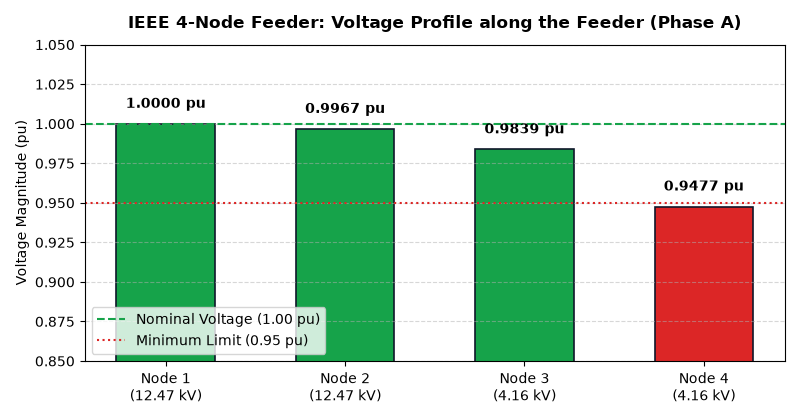

In [ ]:
#@title 6. Plot — voltage profile along the IEEE 4-node feeder
import matplotlib.pyplot as plt

lf = results["load_flow"]
buses = ["node1", "node2", "node3", "node4"]
labels = ["Node 1\n(12.47 kV)", "Node 2\n(12.47 kV)", "Node 3\n(4.16 kV)", "Node 4\n(4.16 kV)"]

voltages = [
    next(row["v_pu"] for row in lf["bus_voltages"] if row["bus"].lower() == b and row["phase" == 1]) if False else
    next(row["v_pu"] for row in lf["bus_voltages"] if row["bus"].lower() == b and row["phase"] == 1)
    for b in buses
]

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#16a34a" if v >= 0.95 else "#dc2626" for v in voltages]
bars = ax.bar(labels, voltages, color=colors, width=0.55, edgecolor="#0f172a", linewidth=1.2)
ax.axhline(1.0, color="#16a34a", linestyle="--", linewidth=1.5, label="Nominal Voltage (1.00 pu)")
ax.axhline(0.95, color="#dc2626", linestyle=":", linewidth=1.5, label="Minimum Limit (0.95 pu)")
ax.set_ylim(0.85, 1.05)
ax.set_ylabel("Voltage Magnitude (pu)")
ax.set_title("IEEE 4-Node Feeder: Voltage Profile along the Feeder (Phase A)", fontweight="bold", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="lower left")

for bar, v in zip(bars, voltages):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008, f"{v:.4f} pu", ha="center", va="bottom", fontfamily="sans-serif", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()


In [7]:
# 6. Verify — check this exact saved run
!cept study verify runs/01-first-circuit --format text

CEPT study check: PASSED
------------------------
Result             Load flow (OpenDSS)
Case fingerprint   38ef70def0c3 (matches the saved case)
Engine             OpenDSS
Run directory      runs/01-first-circuit
Claim              WORKFLOW_VALIDATED

[PASS] Case identity (4 checks)
[PASS] Solver result (3 checks)
[PASS] Saved evidence (7 checks)

For the full check list (14 checks), rerun with --format json.


## 7. Interpret

The IEEE 4-node load flow converged, confirming the expected behavior of a radial distribution system with a step-down transformer:

- **Step-down transformer & phase shift:** Node 1 and Node 2 operate at the 12.47 kV primary level (1.0000 pu and 0.9967 pu). Across transformer T1, voltage drops to 0.9839 pu at Node 3 (4.16 kV) with a -30° phase shift characteristic of the Dyn1 winding connection.
- **Feeder voltage drop:** Along line 3-4, line impedance combined with the 1,800 kW load causes voltage to drop to 0.9477 pu at Node 4 (falling below the 0.95 pu threshold, flagged as **UNDER**).
- **Losses:** Active line and transformer losses total 60.6 kW.

**What this proves:** this CEPT workflow solved and verified the standard IEEE 4-node benchmark against OpenDSS.

**What this does not prove:** acceptance of a real feeder or field installation.

**Try next:** change one declared input in CASE_PAYLOAD, predict the direction of change, restart the kernel, and rerun the lesson.

## Optional — direct OpenDSS comparison

The cells below are for learners who want to inspect the solver route. They are not required for the main CEPT workflow. Run them in order to compare direct OpenDSS readback with the persisted CEPT result.

In [8]:
#@title Under the hood - direct OpenDSS solve (optional)
import opendssdirect as dss

for command in [
    'Clear',
    'New Circuit.ieee4 basekv=12.47 pu=1.0 phases=3 bus1=node1',
    'New Line.line12 bus1=node1.1.2.3 bus2=node2.1.2.3 phases=3 length=0.6096 units=km r1=0.249 x1=0.373 r0=0.536 x0=1.118 c1=0 c0=0',
    'New Transformer.t1 phases=3 windings=2 buses=[node2.1.2.3, node3.1.2.3] kvs=[12.47, 4.16] kvas=[6000, 6000] conns=[delta, wye] %r=1.0 xhl=6.0',
    'New Line.line34 bus1=node3.1.2.3 bus2=node4.1.2.3 phases=3 length=0.7620 units=km r1=0.249 x1=0.373 r0=0.536 x0=1.118 c1=0 c0=0',
    'New Load.load4 bus1=node4.1.2.3 phases=3 conn=wye kv=4.16 kw=1800 pf=0.9',
    'Set Voltagebases=[12.47, 4.16]',
    'CalcVoltageBases',
    'Solve',
]:
    dss.Text.Command(command)
assert dss.Solution.Converged()
print("Direct OpenDSS solve finished: the IEEE 4-node circuit converged.")


Direct OpenDSS solve finished: the circuit converged.


In [9]:
#@title Under the hood — direct OpenDSS readback (optional)
dss.Circuit.SetActiveBus('node4')
direct_values = dss.Bus.puVmagAngle()
direct_by_phase = {phase: float(direct_values[2 * (phase - 1)]) for phase in (1, 2, 3)}
table(['source', 'phase', 'voltage magnitude', 'unit'], [('direct OpenDSS', phase, direct_by_phase[phase], 'pu') for phase in (1, 2, 3)])
assert all(value > 0 for value in direct_by_phase.values())


source          phase  voltage magnitude   unit
--------------  -----  ------------------  ----
direct OpenDSS  1      0.9997586726902581  pu
direct OpenDSS  2      0.9997586726902756  pu
direct OpenDSS  3      0.9997586726902107  pu


In [10]:
#@title Compare solver outputs (optional details)
results = read(RUN_DIR / "results.json")
verify_summary = read(RUN_DIR / "public-verification.json")
cept_rows = [row for row in results["load_flow"]["bus_voltages"] if row["bus"].lower() == "node4"]
cept_by_phase = {row["phase"]: row["v_pu"] for row in cept_rows}
table(
    ["phase", "direct OpenDSS pu", "CEPT pu", "|difference| pu"],
    [(phase, direct_by_phase[phase], cept_by_phase[phase], abs(direct_by_phase[phase] - cept_by_phase[phase])) for phase in (1, 2, 3)],
)
max_abs_diff_pu = max(abs(direct_by_phase[phase] - cept_by_phase[phase]) for phase in (1, 2, 3))
assert max_abs_diff_pu < 0.002
print("Solver output check passed: CEPT matches direct OpenDSS within 0.002 pu.")


phase  direct OpenDSS pu   CEPT pu   |difference| pu
-----  ------------------  --------  ----------------------
1      0.9997586726902581  0.999787  2.8327309741893458e-05
2      0.9997586726902756  0.999787  2.8327309724351935e-05
3      0.9997586726902107  0.999787  2.832730978929998e-05

Direct OpenDSS and CEPT agree
-----------------------------
Result        PASSED
Largest phase difference: 2.83e-05 per unit (limit 1e-4 per unit)
A small difference is rounding, not a different answer.
